#### 02 - Эксперименты с моделями
Цель: Сравнить различные подходы к классификации и выбрать лучшую модель  
Эксперименты:  
1. Baseline: Simple CNN (обучение с нуля)
2. Transfer Learning: ResNet18 (замороженный backbone)
3. Fine-tuning: ResNet18 (размороженный backbone)
4. Сравнение метрик, визуализация результатов

In [9]:
import os
import time
from pathlib import Path
from collections import defaultdict
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tqdm import tqdm

# Добавляем src в путь
import sys
sys.path.append('..')

from src.data.dataset import IntelDataset, get_transforms
from src.models.classifier import LandscapeClassifier

# Настройки
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {DEVICE}')

DATA_DIR = Path('../data')
TRAIN_DIR = DATA_DIR / 'seg_train' / 'seg_train'
TEST_DIR = DATA_DIR / 'seg_test' / 'seg_test'

CLASSES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
NUM_CLASSES = len(CLASSES)
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15

Устройство: cpu


#### Подготовка данных

In [10]:
# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = IntelDataset(str(TRAIN_DIR), transform=train_transform)
test_dataset = IntelDataset(str(TEST_DIR), transform=test_transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train: {len(train_dataset)} изображений')
print(f'Test: {len(test_dataset)} изображений')
print(f'Классы: {CLASSES}')

Train: 14034 изображений
Test: 3000 изображений
Классы: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


#### Утилиты для обучения

In [11]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc='Train', leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for images, labels in tqdm(loader, desc='Eval', leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    return running_loss / len(loader), 100. * correct / total, all_preds, all_labels


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train', marker='o')
    axes[0].plot(history['test_loss'], label='Test', marker='o')
    axes[0].set_title(f'{title} — Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Accuracy
    axes[1].plot(history['train_acc'], label='Train', marker='o')
    axes[1].plot(history['test_acc'], label='Test', marker='o')
    axes[1].set_title(f'{title} — Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'{title} — Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

#### Эксперимент 1: Simple CNN (Baseline)

Epoch  1: Train Loss=1.2619, Acc=45.90% | 
Test Loss=1.0121, Acc=57.33%


Epoch  2: Train Loss=1.0271, Acc=56.78% | 
Test Loss=0.8885, Acc=63.70%


Epoch  3: Train Loss=0.8931, Acc=64.65% | 
Test Loss=0.7373, Acc=71.37%


Epoch  4: Train Loss=0.8021, Acc=69.10% | 
Test Loss=0.6827, Acc=74.67%


Epoch  5: Train Loss=0.7145, Acc=72.90% | 
Test Loss=0.7138, Acc=73.17%


...

Epoch 12: Train Loss=0.4748, Acc=83.28% | 
Test Loss=0.4300, Acc=85.40%


Epoch 13: Train Loss=0.4688, Acc=83.58% | 
Test Loss=0.4191, Acc=84.60%


Epoch 14: Train Loss=0.4508, Acc=84.03% | 
Test Loss=0.4024, Acc=85.73%


Epoch 15: Train Loss=0.4359, Acc=84.89% | 
Test Loss=0.4364, Acc=85.03%


Exception ignored in: <function tqdm.__del__ at 0x000001FC69AEEC00>
Traceback (most recent call last):
  File "c:\Users\ASUS Vivobook Flip S\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\ASUS Vivobook Flip S\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x000001FC69AEEC00>
Traceback (most recent call last):
  File "c:\Users\ASUS Vivobook Flip S\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\ASUS Vivobook Flip S\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'di

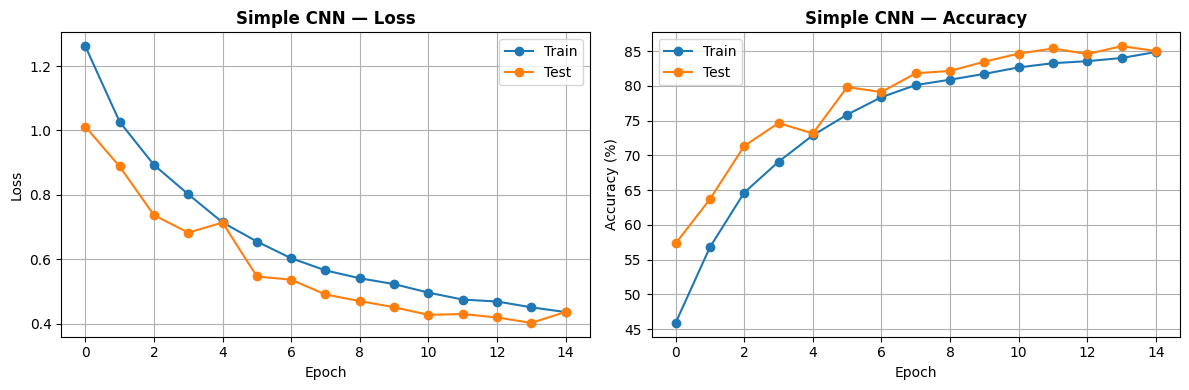

In [12]:
class SimpleCNN(nn.Module):
    """Простая CNN для baseline"""
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Обучение
model_cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)

history_cnn = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model_cnn, train_loader, criterion, optimizer, DEVICE)
    test_loss, test_acc, _, _ = eval_epoch(model_cnn, test_loader, criterion, DEVICE)
    
    history_cnn['train_loss'].append(train_loss)
    history_cnn['test_loss'].append(test_loss)
    history_cnn['train_acc'].append(train_acc)
    history_cnn['test_acc'].append(test_acc)
    
    print(f'Epoch {epoch+1:2d}: Train Loss={train_loss:.4f}, Acc={train_acc:.2f}% | \n'
          f'Test Loss={test_loss:.4f}, Acc={test_acc:.2f}%')

plot_history(history_cnn, 'Simple CNN')

#### Эксперимент 2: ResNet18 (Transfer Learning, frozen backbone)

Epoch  1: Train Loss=0.6026, Acc=80.33% | 
Test Loss=0.3441, Acc=88.27%


Epoch  2: Train Loss=0.3767, Acc=86.52% | 
Test Loss=0.3224, Acc=88.40%


Epoch  3: Train Loss=0.3622, Acc=86.85% | 
Test Loss=0.2847, Acc=89.93%


Epoch  4: Train Loss=0.3424, Acc=87.30% | 
Test Loss=0.2924, Acc=89.27%


Epoch  5: Train Loss=0.3377, Acc=87.65% | 
Test Loss=0.2771, Acc=89.67%


...

Epoch 11: Train Loss=0.3065, Acc=89.18% | 
Test Loss=0.2617, Acc=90.57%


Epoch 12: Train Loss=0.2999, Acc=88.83% | 
Test Loss=0.2670, Acc=90.03%


Epoch 13: Train Loss=0.3047, Acc=88.86% | 
Test Loss=0.2634, Acc=90.30%


Epoch 14: Train Loss=0.3052, Acc=88.93% | 
Test Loss=0.2727, Acc=90.30%


Epoch 15: Train Loss=0.2969, Acc=89.32% | 
Test Loss=0.2591, Acc=90.63%


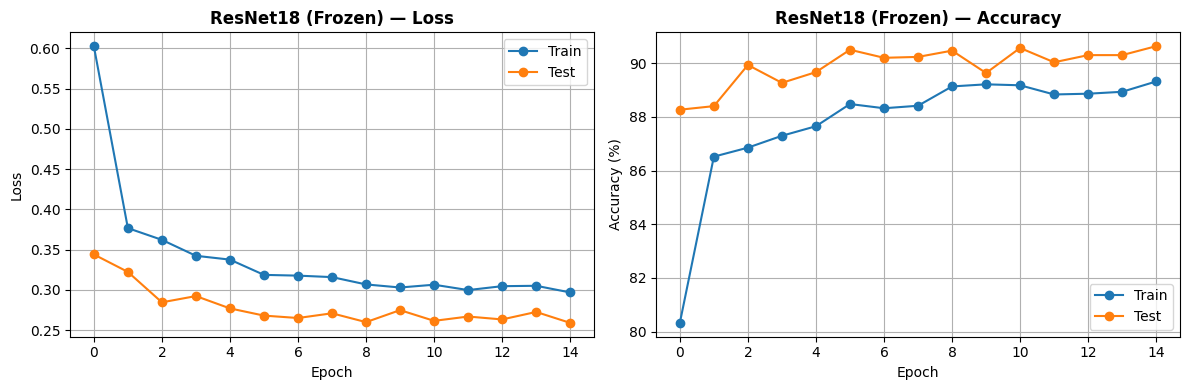

In [13]:
model_resnet_frozen = LandscapeClassifier(NUM_CLASSES, backbone='resnet18', pretrained=True).to(DEVICE)
model_resnet_frozen.freeze_backbone()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_resnet_frozen.parameters()), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history_resnet_frozen = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model_resnet_frozen, train_loader, criterion, optimizer, DEVICE)
    test_loss, test_acc, _, _ = eval_epoch(model_resnet_frozen, test_loader, criterion, DEVICE)
    scheduler.step()
    
    history_resnet_frozen['train_loss'].append(train_loss)
    history_resnet_frozen['test_loss'].append(test_loss)
    history_resnet_frozen['train_acc'].append(train_acc)
    history_resnet_frozen['test_acc'].append(test_acc)
    
    print(f'Epoch {epoch+1:2d}: Train Loss={train_loss:.4f}, Acc={train_acc:.2f}% | \n'
          f'Test Loss={test_loss:.4f}, Acc={test_acc:.2f}%')

plot_history(history_resnet_frozen, 'ResNet18 (Frozen)')

#### Эксперимент 3: ResNet18 (Fine-tuning)

Этап 1: заморозка backbone (5 эпох)


Epoch  1: Train Loss=0.6020, Acc=79.98% | 
Test Loss=0.3314, Acc=88.27%


Epoch  2: Train Loss=0.3854, Acc=86.39% | 
Test Loss=0.2977, Acc=89.20%


Epoch  3: Train Loss=0.3566, Acc=87.27% | 
Test Loss=0.2827, Acc=89.70%


Epoch  4: Train Loss=0.3455, Acc=87.64% | 
Test Loss=0.3036, Acc=89.00%


...

Epoch 11: Train Loss=0.0717, Acc=97.43% | 
Test Loss=0.2087, Acc=93.67%


Epoch 12: Train Loss=0.0457, Acc=98.40% | 
Test Loss=0.1945, Acc=93.77%


Epoch 13: Train Loss=0.0356, Acc=98.78% | 
Test Loss=0.2140, Acc=93.47%


Epoch 14: Train Loss=0.0266, Acc=99.18% | 
Test Loss=0.2323, Acc=94.07%


Epoch 15: Train Loss=0.0213, Acc=99.33% | 
Test Loss=0.2190, Acc=94.03%

Модель сохранена в artifacts/model_best.pth


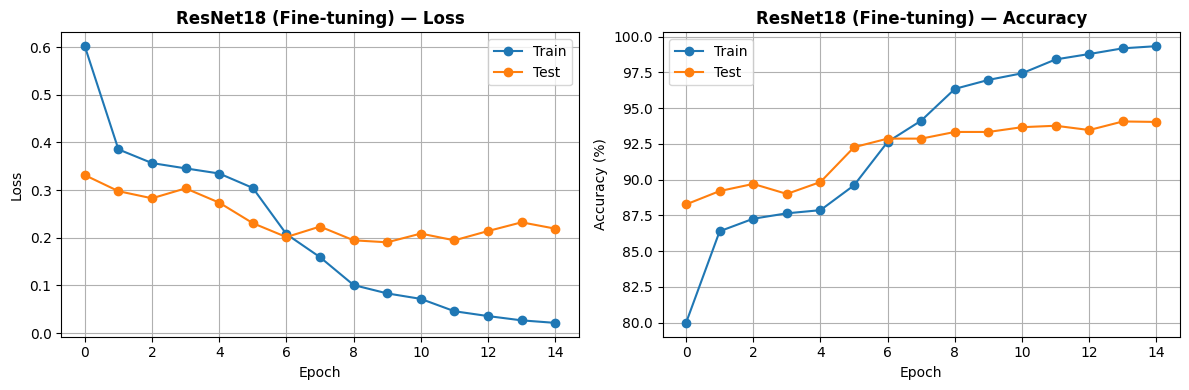

In [14]:
model_resnet_ft = LandscapeClassifier(NUM_CLASSES, backbone='resnet18', pretrained=True).to(DEVICE)

# Этап 1: заморозка backbone (5 эпох)
model_resnet_ft.freeze_backbone()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_resnet_ft.parameters()), lr=0.001)

history_resnet_ft = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

print('Этап 1: заморозка backbone (5 эпох)')
for epoch in range(5):
    train_loss, train_acc = train_epoch(model_resnet_ft, train_loader, criterion, optimizer, DEVICE)
    test_loss, test_acc, _, _ = eval_epoch(model_resnet_ft, test_loader, criterion, DEVICE)
    
    history_resnet_ft['train_loss'].append(train_loss)
    history_resnet_ft['test_loss'].append(test_loss)
    history_resnet_ft['train_acc'].append(train_acc)
    history_resnet_ft['test_acc'].append(test_acc)
    
    print(f'Epoch {epoch+1:2d}: Train Loss={train_loss:.4f}, Acc={train_acc:.2f}% | \n'
          f'Test Loss={test_loss:.4f}, Acc={test_acc:.2f}%')

# Этап 2: разморозка backbone (10 эпох)
model_resnet_ft.unfreeze_backbone()
optimizer = optim.Adam(model_resnet_ft.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

print('\nЭтап 2: разморозка backbone (10 эпох)')
for epoch in range(5, EPOCHS):
    train_loss, train_acc = train_epoch(model_resnet_ft, train_loader, criterion, optimizer, DEVICE)
    test_loss, test_acc, y_pred, y_true = eval_epoch(model_resnet_ft, test_loader, criterion, DEVICE)
    scheduler.step()
    
    history_resnet_ft['train_loss'].append(train_loss)
    history_resnet_ft['test_loss'].append(test_loss)
    history_resnet_ft['train_acc'].append(train_acc)
    history_resnet_ft['test_acc'].append(test_acc)
    
    print(f'Epoch {epoch+1:2d}: Train Loss={train_loss:.4f}, Acc={train_acc:.2f}% | \n'
          f'Test Loss={test_loss:.4f}, Acc={test_acc:.2f}%')

# Сохраняем лучшую модель
os.makedirs('../artifacts', exist_ok=True)
torch.save(model_resnet_ft.state_dict(), '../artifacts/model_best.pth')
print('\nМодель сохранена в artifacts/model_best.pth')

plot_history(history_resnet_ft, 'ResNet18 (Fine-tuning)')

#### Сравнение моделей

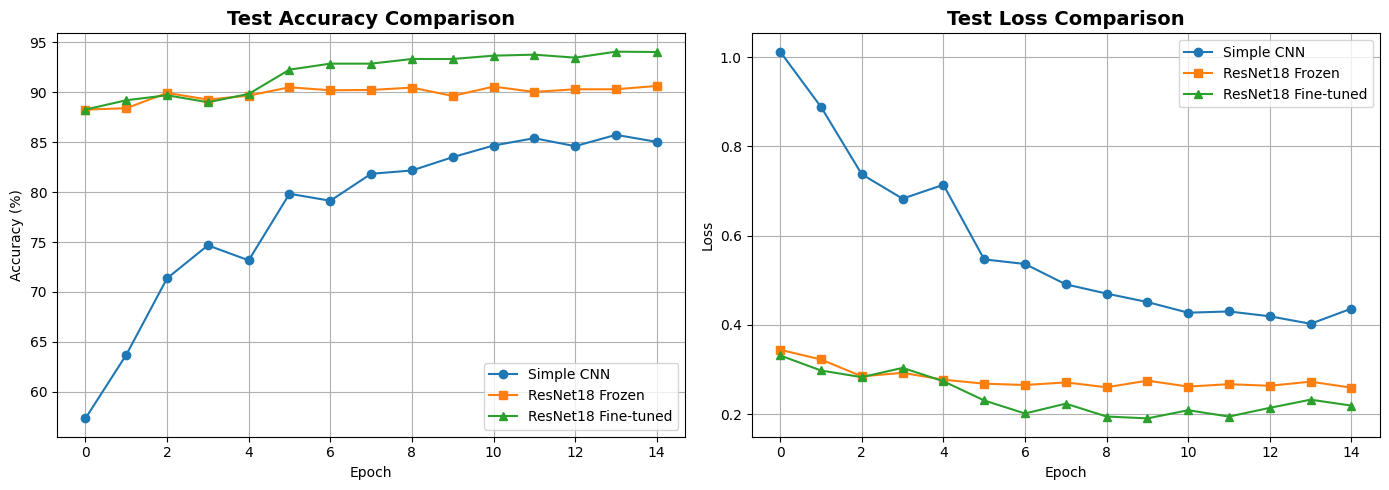


ИТОГОВЫЕ РЕЗУЛЬТАТЫ (Test Accuracy):
Simple CNN:           85.03%
ResNet18 Frozen:      90.63%
ResNet18 Fine-tuned:  94.03%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test Accuracy comparison
axes[0].plot(history_cnn['test_acc'], label='Simple CNN', marker='o')
axes[0].plot(history_resnet_frozen['test_acc'], label='ResNet18 Frozen', marker='s')
axes[0].plot(history_resnet_ft['test_acc'], label='ResNet18 Fine-tuned', marker='^')
axes[0].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True)

# Test Loss comparison
axes[1].plot(history_cnn['test_loss'], label='Simple CNN', marker='o')
axes[1].plot(history_resnet_frozen['test_loss'], label='ResNet18 Frozen', marker='s')
axes[1].plot(history_resnet_ft['test_loss'], label='ResNet18 Fine-tuned', marker='^')
axes[1].set_title('Test Loss Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../artifacts/models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Итоговые метрики
print('\n' + '=' * 50)
print('ИТОГОВЫЕ РЕЗУЛЬТАТЫ (Test Accuracy):')
print('=' * 50)
print(f"Simple CNN:           {history_cnn['test_acc'][-1]:.2f}%")
print(f"ResNet18 Frozen:      {history_resnet_frozen['test_acc'][-1]:.2f}%")
print(f"ResNet18 Fine-tuned:  {history_resnet_ft['test_acc'][-1]:.2f}%")

#### Confusion Matrix для лучшей модели

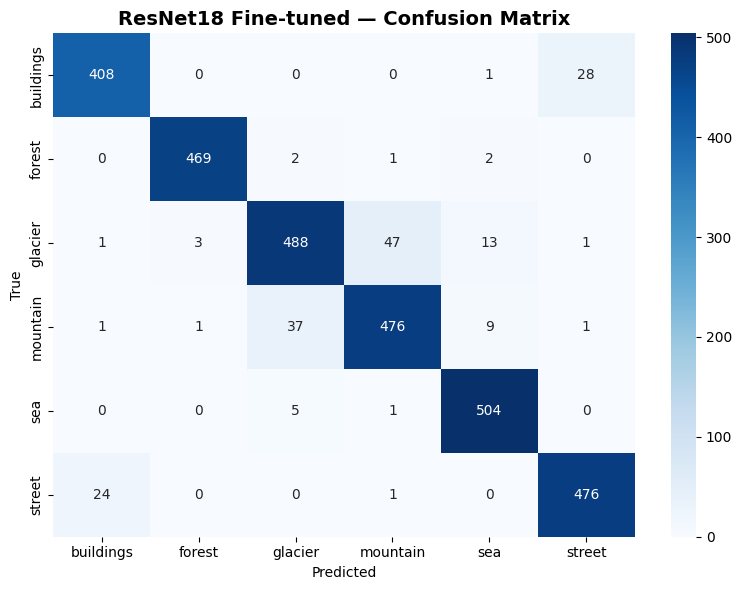


Classification Report:
              precision    recall  f1-score   support

   buildings       0.94      0.93      0.94       437
      forest       0.99      0.99      0.99       474
     glacier       0.92      0.88      0.90       553
    mountain       0.90      0.91      0.91       525
         sea       0.95      0.99      0.97       510
      street       0.94      0.95      0.95       501

    accuracy                           0.94      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000



In [16]:
# Переоцениваем лучшую модель на тесте для получения предсказаний
model_resnet_ft.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model_resnet_ft(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

plot_confusion_matrix(all_labels, all_preds, 'ResNet18 Fine-tuned')

# Classification report
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=CLASSES))

#### Анализ ошибок

Всего ошибок: 179 / 3000 (5.97%)


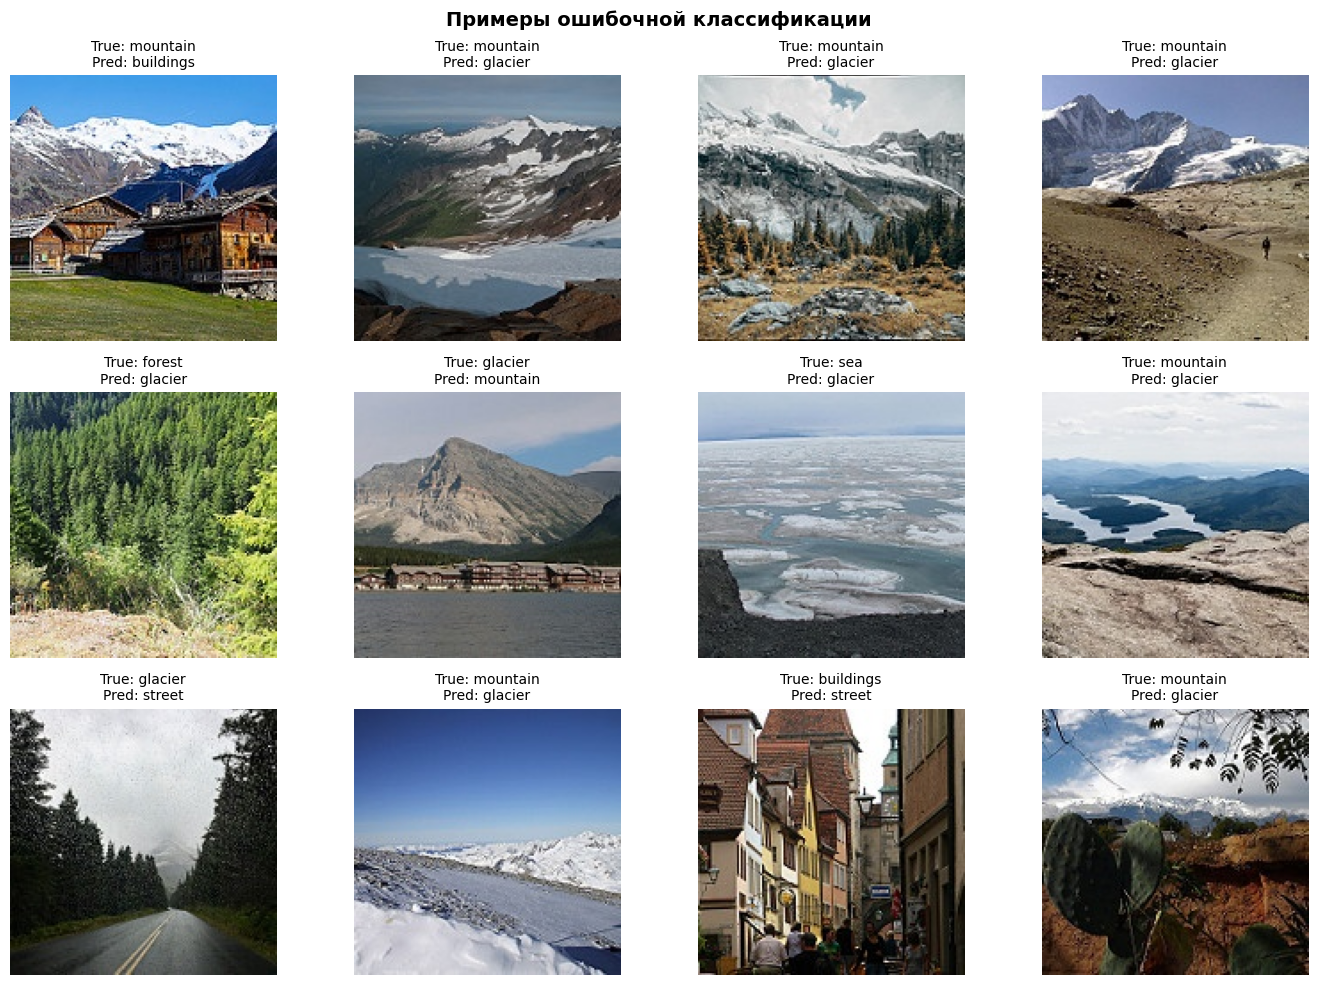

In [17]:
# Найдем примеры неправильной классификации
errors = [(i, true, pred) for i, (true, pred) in enumerate(zip(all_labels, all_preds)) if true != pred]
print(f'Всего ошибок: {len(errors)} / {len(all_labels)} ({100*len(errors)/len(all_labels):.2f}%)')

# Покажем случайные 12 ошибок
sample_errors = random.sample(errors, min(12, len(errors)))

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for idx, (img_idx, true, pred) in enumerate(sample_errors):
    # Получаем изображение из датасета
    img_path = test_dataset.samples[img_idx][0]
    img = Image.open(img_path)
    
    axes[idx].imshow(img)
    axes[idx].set_title(f'True: {CLASSES[true]}\nPred: {CLASSES[pred]}', fontsize=10)
    axes[idx].axis('off')

plt.suptitle('Примеры ошибочной классификации', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

#### Выводы

1. **Simple CNN** показал 85.03% accuracy.Результат неплохой, но явно видно переобучение: train accuracy ушла почти до 100%, а test застряла на 85%. Также явно видно, что недостаточно данных и параметров, чтобы выучить сложные признаки ландшафтов

2. **ResNet18 Frozen** - 90.63% accuracy. Transfer learning сработал отлично, так как уже с первых эпох accuracy выше 88%, и модель стабильно держится около 90%. Заморозка backbone позволяет быстро адаптировать предобученные признаки под наш домен, не рискуя испортить веса

3. **ResNet18 Fine-tuned** - 94.03% accuracy, лучший результат. Двухэтапное обучение (сначала frozen, потом unfreeze с маленьким lr) дало прирост +3.4% по сравнению с frozen. Fine-tuning позволил подстроить низкоуровневые признаки (текстуры, цвета) под конкретный датасет

4. **Основные ошибки:**
   - `glacier` и `mountain` (84 ошибки между этими классами. Снежные скалы и горные пики визуально очень похожи, модель путает их чаще всего)
   - `buildings` и `street` (53 ошибки, здания часто попадают в кадр улиц, и наоборот)

5. **Рекомендация:** Использовать ResNet18 с fine-tuning для production, из-за баланса точности (около 94%), скорости и стабильности обучения